In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

In [122]:
df = pd.read_csv("star_classification.csv")
device = "cuda" if torch.cuda.is_available() else "cpu"

In [123]:
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [125]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237665e+18,8.438560e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


In [126]:
label_map = {
    "GALAXY": 0,
    "STAR": 1,
    "QSO": 2
}

y = df["class"].map(label_map)
X = df.drop(columns=["class"])

In [127]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [128]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train.values, dtype=torch.long)
y_val_t   = torch.tensor(y_val.values, dtype=torch.long)
y_test_t  = torch.tensor(y_test.values, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=512,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=512,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=512,
    shuffle=False,
    pin_memory=True
)



In [129]:
torch.manual_seed(42)
model = nn.Sequential(
  nn.Linear(17, 50),
  nn.ReLU(),
  nn.Linear(50, 40),
  nn.ReLU(),
  nn.Linear(40, 3)
).to(device)

In [130]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def train(model, optimizer, criterion, train_loader, n_epochs):
    model.train()
    for epoch in range(n_epochs):
        total_loss = 0.
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Cálculo da acurácia
            _, predicted = torch.max(y_pred.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

        mean_loss = total_loss / len(train_loader)
        accuracy = 100 * correct / total
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Accuracy: {accuracy:.2f}%")

In [131]:
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [132]:
train(model, optimizer, criterion, train_loader, n_epochs=20)

Epoch 1/20, Loss: 0.7218, Accuracy: 68.77%
Epoch 2/20, Loss: 0.3087, Accuracy: 90.63%
Epoch 3/20, Loss: 0.2075, Accuracy: 93.72%
Epoch 4/20, Loss: 0.1715, Accuracy: 94.85%
Epoch 5/20, Loss: 0.1557, Accuracy: 95.36%
Epoch 6/20, Loss: 0.1457, Accuracy: 95.63%
Epoch 7/20, Loss: 0.1392, Accuracy: 95.87%
Epoch 8/20, Loss: 0.1333, Accuracy: 96.05%
Epoch 9/20, Loss: 0.1287, Accuracy: 96.21%
Epoch 10/20, Loss: 0.1253, Accuracy: 96.27%
Epoch 11/20, Loss: 0.1221, Accuracy: 96.37%
Epoch 12/20, Loss: 0.1204, Accuracy: 96.39%
Epoch 13/20, Loss: 0.1171, Accuracy: 96.55%
Epoch 14/20, Loss: 0.1157, Accuracy: 96.58%
Epoch 15/20, Loss: 0.1140, Accuracy: 96.63%
Epoch 16/20, Loss: 0.1129, Accuracy: 96.66%
Epoch 17/20, Loss: 0.1114, Accuracy: 96.71%
Epoch 18/20, Loss: 0.1103, Accuracy: 96.75%
Epoch 19/20, Loss: 0.1093, Accuracy: 96.76%
Epoch 20/20, Loss: 0.1093, Accuracy: 96.73%


### Avaliação Final no Conjunto de Teste
Agora que o modelo foi treinado rapidamente usando a GPU, vamos verificar seu desempenho final.

In [133]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    return 100 * correct / total

test_acc = evaluate(model, test_loader)
print(f"Acurácia no conjunto de Teste: {test_acc:.2f}%")

Acurácia no conjunto de Teste: 96.88%


### Verificação de Integridade e Classificação
Vamos validar se o processamento dos dados respeitou as categorias originais do CSV.

Mapeamento utilizado: {'GALAXY': 0, 'STAR': 1, 'QSO': 2}
Total de registros no CSV: 100000


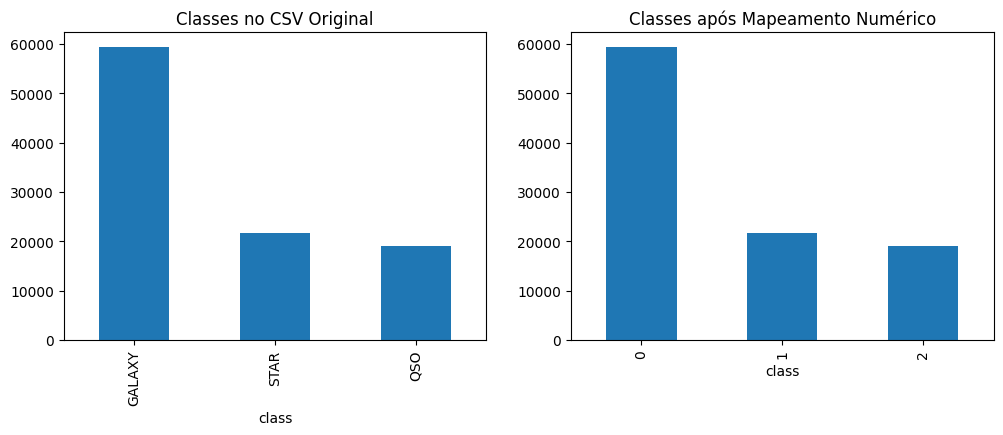

In [134]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Verificar se as classes foram mapeadas corretamente
print("Mapeamento utilizado:", label_map)
print(f"Total de registros no CSV: {len(df)}")

# 2. Distribuição Real vs Mapeada
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df['class'].value_counts().plot(kind='bar', title='Classes no CSV Original')
plt.subplot(1, 2, 2)
y.value_counts().plot(kind='bar', title='Classes após Mapeamento Numérico')
plt.show()

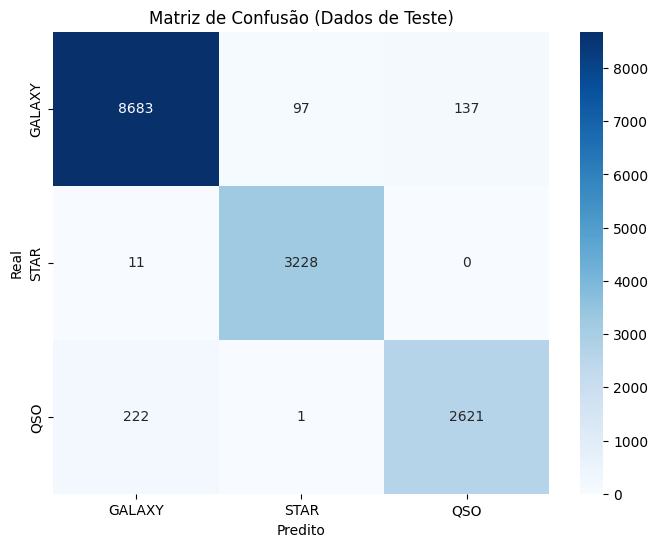


Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97      8917
        STAR       0.97      1.00      0.98      3239
         QSO       0.95      0.92      0.94      2844

    accuracy                           0.97     15000
   macro avg       0.96      0.96      0.96     15000
weighted avg       0.97      0.97      0.97     15000



In [135]:
# 3. Gerar Matriz de Confusão para ver os erros de classificação detalhados
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    return all_labels, all_preds

y_true, y_pred = get_predictions(model, test_loader)

# Inverter o mapa para legendas legíveis
inv_label_map = {v: k for k, v in label_map.items()}
target_names = [inv_label_map[i] for i in range(3)]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Dados de Teste)')
plt.show()

print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Começo dos testes e mudanças
Vou começar variando a largura do modelo para ser mais larga e posteriomente menos larga que o modelo base para visualizar o impacto dessa alteração

In [136]:

model = nn.Sequential(
  nn.Linear(17, 400),
  nn.ReLU(),
  nn.Linear(400, 320),
  nn.ReLU(),
  nn.Linear(320, 3)
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


print("Iniciando treino com nova largura...")
train(model, optimizer, criterion, train_loader, n_epochs=20)

Iniciando treino com nova largura...
Epoch 1/20, Loss: 0.3365, Accuracy: 88.12%
Epoch 2/20, Loss: 0.1658, Accuracy: 94.87%
Epoch 3/20, Loss: 0.1444, Accuracy: 95.65%
Epoch 4/20, Loss: 0.1325, Accuracy: 95.97%
Epoch 5/20, Loss: 0.1237, Accuracy: 96.31%
Epoch 6/20, Loss: 0.1365, Accuracy: 95.91%
Epoch 7/20, Loss: 0.1204, Accuracy: 96.32%
Epoch 8/20, Loss: 0.1154, Accuracy: 96.50%
Epoch 9/20, Loss: 0.1109, Accuracy: 96.65%
Epoch 10/20, Loss: 0.1114, Accuracy: 96.58%
Epoch 11/20, Loss: 0.1089, Accuracy: 96.65%
Epoch 12/20, Loss: 0.1069, Accuracy: 96.74%
Epoch 13/20, Loss: 0.1055, Accuracy: 96.74%
Epoch 14/20, Loss: 0.1039, Accuracy: 96.80%
Epoch 15/20, Loss: 0.1037, Accuracy: 96.76%
Epoch 16/20, Loss: 0.1013, Accuracy: 96.89%
Epoch 17/20, Loss: 0.1019, Accuracy: 96.79%
Epoch 18/20, Loss: 0.0990, Accuracy: 96.90%
Epoch 19/20, Loss: 0.0997, Accuracy: 96.84%
Epoch 20/20, Loss: 0.0983, Accuracy: 96.91%


In [137]:

test_acc = evaluate(model, test_loader)
print(f"Acurácia no conjunto de Teste: {test_acc:.2f}%")

Acurácia no conjunto de Teste: 96.43%


A acurácia não mudou significativamente do ultimo teste com uma largura média, vamos ver agora como o modelo se comporta com uma largura menor

In [138]:

model = nn.Sequential(
  nn.Linear(17, 2),
  nn.ReLU(),
  nn.Linear(2, 2),
  nn.ReLU(),
  nn.Linear(2, 3)
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


print("Iniciando treino com nova largura...")
train(model, optimizer, criterion, train_loader, n_epochs=20)

Iniciando treino com nova largura...
Epoch 1/20, Loss: 1.0728, Accuracy: 51.54%
Epoch 2/20, Loss: 0.9971, Accuracy: 61.66%
Epoch 3/20, Loss: 0.8910, Accuracy: 69.54%
Epoch 4/20, Loss: 0.7954, Accuracy: 72.37%
Epoch 5/20, Loss: 0.7301, Accuracy: 74.50%
Epoch 6/20, Loss: 0.6896, Accuracy: 74.99%
Epoch 7/20, Loss: 0.6646, Accuracy: 75.04%
Epoch 8/20, Loss: 0.6471, Accuracy: 75.06%
Epoch 9/20, Loss: 0.6339, Accuracy: 75.06%
Epoch 10/20, Loss: 0.6235, Accuracy: 75.05%
Epoch 11/20, Loss: 0.6147, Accuracy: 75.05%
Epoch 12/20, Loss: 0.6065, Accuracy: 75.05%
Epoch 13/20, Loss: 0.5974, Accuracy: 74.97%
Epoch 14/20, Loss: 0.5750, Accuracy: 74.79%
Epoch 15/20, Loss: 0.5277, Accuracy: 74.60%
Epoch 16/20, Loss: 0.4778, Accuracy: 74.48%
Epoch 17/20, Loss: 0.4377, Accuracy: 74.37%
Epoch 18/20, Loss: 0.4066, Accuracy: 83.37%
Epoch 19/20, Loss: 0.3822, Accuracy: 90.71%
Epoch 20/20, Loss: 0.3622, Accuracy: 91.14%


In [139]:
test_acc = evaluate(model, test_loader)
print(f"Acurácia no conjunto de Teste: {test_acc:.2f}%")

Acurácia no conjunto de Teste: 91.36%


A acurácia do modelo diminui com a redução drástica de tamanho, mas não drasticamente, isso se da pela natureza do problema, o sistema consegue reconhecer padroes facilmente, mesmo após serem comprimido para duas dimensões.

Agora vamos para os testes de profundidade.
Novamente vamos primeiro aumentar e ver os resultados depois diminuir a profundidade.


In [140]:
model = nn.Sequential(
  nn.Linear(17, 50),
  nn.ReLU(),
  nn.Linear(50, 60),
  nn.ReLU(),
  nn.Linear(60, 50),
  nn.ReLU(),
  nn.Linear(50, 40),
  nn.ReLU(),
  nn.Linear(40, 3)
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


print("Iniciando treino com nova prufundidade...")
train(model, optimizer, criterion, train_loader, n_epochs=20)

Iniciando treino com nova prufundidade...
Epoch 1/20, Loss: 0.6449, Accuracy: 71.70%
Epoch 2/20, Loss: 0.2279, Accuracy: 93.17%
Epoch 3/20, Loss: 0.1835, Accuracy: 94.40%
Epoch 4/20, Loss: 0.1585, Accuracy: 95.09%
Epoch 5/20, Loss: 0.1433, Accuracy: 95.58%
Epoch 6/20, Loss: 0.1346, Accuracy: 95.89%
Epoch 7/20, Loss: 0.1292, Accuracy: 96.02%
Epoch 8/20, Loss: 0.1276, Accuracy: 96.06%
Epoch 9/20, Loss: 0.1230, Accuracy: 96.26%
Epoch 10/20, Loss: 0.1206, Accuracy: 96.32%
Epoch 11/20, Loss: 0.1180, Accuracy: 96.45%
Epoch 12/20, Loss: 0.1172, Accuracy: 96.44%
Epoch 13/20, Loss: 0.1157, Accuracy: 96.50%
Epoch 14/20, Loss: 0.1124, Accuracy: 96.59%
Epoch 15/20, Loss: 0.1117, Accuracy: 96.62%
Epoch 16/20, Loss: 0.1124, Accuracy: 96.53%
Epoch 17/20, Loss: 0.1085, Accuracy: 96.71%
Epoch 18/20, Loss: 0.1087, Accuracy: 96.67%
Epoch 19/20, Loss: 0.1070, Accuracy: 96.69%
Epoch 20/20, Loss: 0.1080, Accuracy: 96.64%


In [141]:
test_acc = evaluate(model, test_loader)
print(f"Acurácia no conjunto de Teste: {test_acc:.2f}%")

Acurácia no conjunto de Teste: 96.83%


O aumento de profundidade não causa impacto grande na acurácia do modelo, podendo até criar overfitting se exagerada, isso se deve novamente a natureza do dataset, o modelo consegue aprender como classíficar a maioria dos casos facilmente, não necessitando de tantas camadas

Vamos agora criar um modelo raso


In [142]:
model = nn.Sequential(
  nn.Linear(17, 50),
  nn.ReLU(),
  nn.Linear(50, 3)
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


print("Iniciando treino com nova prufundidade(raso)...")
train(model, optimizer, criterion, train_loader, n_epochs=20)
test_acc = evaluate(model, test_loader)
print(f"Acurácia no conjunto de Teste: {test_acc:.2f}%")

Iniciando treino com nova prufundidade(raso)...
Epoch 1/20, Loss: 0.8544, Accuracy: 62.08%
Epoch 2/20, Loss: 0.5651, Accuracy: 76.42%
Epoch 3/20, Loss: 0.3980, Accuracy: 86.72%
Epoch 4/20, Loss: 0.3055, Accuracy: 90.69%
Epoch 5/20, Loss: 0.2581, Accuracy: 92.13%
Epoch 6/20, Loss: 0.2311, Accuracy: 92.95%
Epoch 7/20, Loss: 0.2135, Accuracy: 93.56%
Epoch 8/20, Loss: 0.2004, Accuracy: 93.93%
Epoch 9/20, Loss: 0.1904, Accuracy: 94.27%
Epoch 10/20, Loss: 0.1821, Accuracy: 94.53%
Epoch 11/20, Loss: 0.1748, Accuracy: 94.82%
Epoch 12/20, Loss: 0.1690, Accuracy: 94.95%
Epoch 13/20, Loss: 0.1641, Accuracy: 95.12%
Epoch 14/20, Loss: 0.1596, Accuracy: 95.31%
Epoch 15/20, Loss: 0.1560, Accuracy: 95.43%
Epoch 16/20, Loss: 0.1529, Accuracy: 95.53%
Epoch 17/20, Loss: 0.1497, Accuracy: 95.62%
Epoch 18/20, Loss: 0.1470, Accuracy: 95.71%
Epoch 19/20, Loss: 0.1443, Accuracy: 95.80%
Epoch 20/20, Loss: 0.1422, Accuracy: 95.85%
Acurácia no conjunto de Teste: 96.07%


Como esperado o modelo não mudou de forma consideravel pelos motívos descritos previamente

#Testes com mudanças de numero de épocas e learning rate

Vamos começar primeiro variando o numero de épocas para msior e depois para menor e vermos como isso impacta o modelo

In [145]:
model = nn.Sequential(
  nn.Linear(17, 50),
  nn.ReLU(),
  nn.Linear(50, 40),
  nn.ReLU(),
  nn.Linear(40, 3)
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


print("Iniciando treino com nova prufundidade(raso)...")
train(model, optimizer, criterion, train_loader, n_epochs=50)
test_acc = evaluate(model, test_loader)
print(f"Acurácia no conjunto de Teste: {test_acc:.2f}%")

Iniciando treino com nova prufundidade(raso)...
Epoch 1/50, Loss: 0.7460, Accuracy: 67.44%
Epoch 2/50, Loss: 0.3191, Accuracy: 89.87%
Epoch 3/50, Loss: 0.2082, Accuracy: 93.83%
Epoch 4/50, Loss: 0.1738, Accuracy: 94.83%
Epoch 5/50, Loss: 0.1568, Accuracy: 95.28%
Epoch 6/50, Loss: 0.1469, Accuracy: 95.64%
Epoch 7/50, Loss: 0.1393, Accuracy: 95.83%
Epoch 8/50, Loss: 0.1356, Accuracy: 95.94%
Epoch 9/50, Loss: 0.1314, Accuracy: 96.15%
Epoch 10/50, Loss: 0.1276, Accuracy: 96.24%
Epoch 11/50, Loss: 0.1246, Accuracy: 96.36%
Epoch 12/50, Loss: 0.1220, Accuracy: 96.39%
Epoch 13/50, Loss: 0.1198, Accuracy: 96.46%
Epoch 14/50, Loss: 0.1180, Accuracy: 96.54%
Epoch 15/50, Loss: 0.1171, Accuracy: 96.53%
Epoch 16/50, Loss: 0.1153, Accuracy: 96.58%
Epoch 17/50, Loss: 0.1141, Accuracy: 96.60%
Epoch 18/50, Loss: 0.1127, Accuracy: 96.69%
Epoch 19/50, Loss: 0.1121, Accuracy: 96.67%
Epoch 20/50, Loss: 0.1105, Accuracy: 96.74%
Epoch 21/50, Loss: 0.1100, Accuracy: 96.75%
Epoch 22/50, Loss: 0.1094, Accuracy: 

In [146]:
model = nn.Sequential(
  nn.Linear(17, 50),
  nn.ReLU(),
  nn.Linear(50, 40),
  nn.ReLU(),
  nn.Linear(40, 3)
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


print("Iniciando treino com nova prufundidade(raso)...")
train(model, optimizer, criterion, train_loader, n_epochs=5)
test_acc = evaluate(model, test_loader)
print(f"Acurácia no conjunto de Teste: {test_acc:.2f}%")

Iniciando treino com nova prufundidade(raso)...
Epoch 1/5, Loss: 0.7561, Accuracy: 66.65%
Epoch 2/5, Loss: 0.3092, Accuracy: 90.63%
Epoch 3/5, Loss: 0.2081, Accuracy: 93.58%
Epoch 4/5, Loss: 0.1774, Accuracy: 94.59%
Epoch 5/5, Loss: 0.1609, Accuracy: 95.19%
Acurácia no conjunto de Teste: 95.23%


Ao se executarem mais épocas o modelo performa melhor que ao se executarem menos, mas o aumento do ganha diminui exponencialmente, enquanto o custo de execução aumenta proporcionalmente ao numero de épocas

### Experimento de Hiperparâmetros: Identificando Underfitting e Overfitting
Vamos criar uma função de treino mais completa que rastreia o histórico de perda (loss) para visualização.

In [154]:
def train_with_history(model, optimizer, criterion, train_loader, val_loader, n_epochs):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(n_epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            preds = model(X_b)
            loss = criterion(preds, y_b)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(preds.data, 1)
            train_total += y_b.size(0)
            train_correct += (predicted == y_b).sum().item()

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds = model(X_b)
                loss_val = criterion(preds, y_b)
                val_loss += loss_val.item()
                _, predicted = torch.max(preds.data, 1)
                val_total += y_b.size(0)
                val_correct += (predicted == y_b).sum().item()

        # Cálculo de métricas médias
        t_loss = train_loss/len(train_loader)
        v_loss = val_loss/len(val_loader)
        t_acc = 100 * train_correct / train_total
        v_acc = 100 * val_correct / val_total

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        print(f"Epoch {epoch + 1}/{n_epochs} -> Train Loss: {t_loss:.4f}, Train Acc: {t_acc:.2f}% | Val Loss: {v_loss:.4f}, Val Acc: {v_acc:.2f}%")

    return history

#### Cenário 1: Learning Rate muito alto (Risco de Overfitting/Instabilidade)

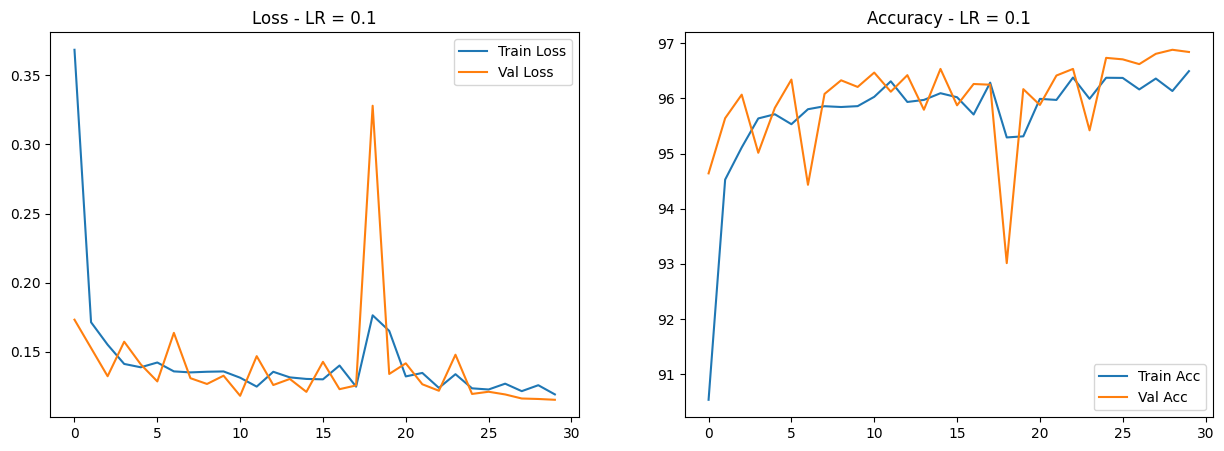

In [148]:
model_high = nn.Sequential(nn.Linear(17, 100), nn.ReLU(), nn.Linear(100, 3)).to(device)

optimizer = torch.optim.Adam(model_high.parameters(), lr=0.1)
history_high = train_with_history(model_high, optimizer, nn.CrossEntropyLoss(), train_loader, val_loader, n_epochs=30)
plot_history(history_high, "LR = 0.1")

#### Cenário 2: Learning Rate muito baixo (Underfitting)

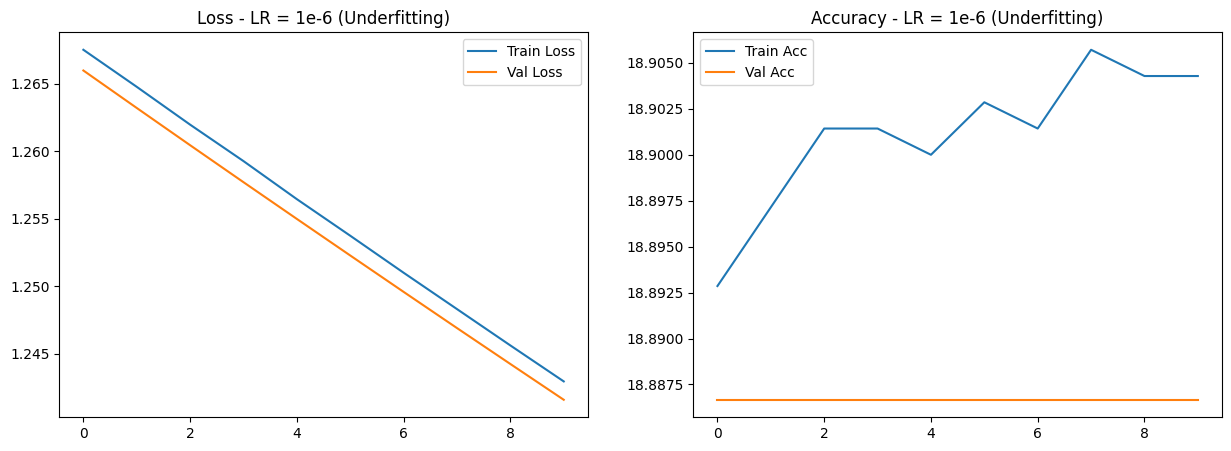

In [149]:
model_low = nn.Sequential(nn.Linear(17, 100), nn.ReLU(), nn.Linear(100, 3)).to(device)

optimizer = torch.optim.Adam(model_low.parameters(), lr=1e-6)
history_low = train_with_history(model_low, optimizer, nn.CrossEntropyLoss(), train_loader, val_loader, n_epochs=10)
plot_history(history_low, "LR = 1e-6 (Underfitting)")

#### Cenário 3: O Ponto Ideal (Balanced Training)
Vamos utilizar um learning rate moderado (0.001) e um número maior de épocas para observar o comportamento de convergência estável.

Treinando modelo ideal por 50 épocas...


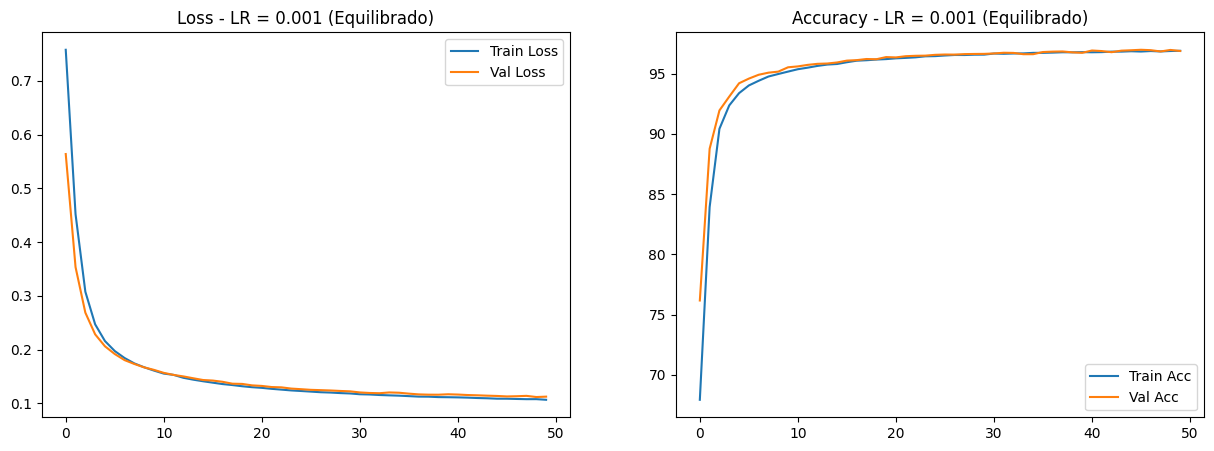

In [150]:
model_ideal = nn.Sequential(
    nn.Linear(17, 100),
    nn.ReLU(),
    nn.Linear(100, 3)
).to(device)


optimizer = torch.optim.Adam(model_ideal.parameters(), lr=0.001)

print("Treinando modelo ideal por 50 épocas...")
history_ideal = train_with_history(model_ideal, optimizer, nn.CrossEntropyLoss(), train_loader, val_loader, n_epochs=50)
plot_history(history_ideal, "LR = 0.001 (Equilibrado)")

#Testando o efeito da Regularização e outros métodos de otimização

### 1. Testando Adam com Regularização L2 (Weight Decay)
Vamos adicionar o parâmetro `weight_decay` ao otimizador Adam.

Treinando com Adam + L2 (Weight Decay)...
Epoch 1/30 -> Train Loss: 0.7400, Train Acc: 67.16% | Val Loss: 0.4252, Val Acc: 87.19%
Epoch 2/30 -> Train Loss: 0.2890, Train Acc: 91.15% | Val Loss: 0.2178, Val Acc: 93.44%
Epoch 3/30 -> Train Loss: 0.2037, Train Acc: 93.81% | Val Loss: 0.1835, Val Acc: 94.51%
Epoch 4/30 -> Train Loss: 0.1706, Train Acc: 94.69% | Val Loss: 0.1637, Val Acc: 95.12%
Epoch 5/30 -> Train Loss: 0.1565, Train Acc: 95.19% | Val Loss: 0.1548, Val Acc: 95.47%
Epoch 6/30 -> Train Loss: 0.1468, Train Acc: 95.59% | Val Loss: 0.1475, Val Acc: 95.77%
Epoch 7/30 -> Train Loss: 0.1401, Train Acc: 95.88% | Val Loss: 0.1438, Val Acc: 95.86%
Epoch 8/30 -> Train Loss: 0.1342, Train Acc: 96.03% | Val Loss: 0.1377, Val Acc: 96.17%
Epoch 9/30 -> Train Loss: 0.1308, Train Acc: 96.15% | Val Loss: 0.1333, Val Acc: 96.29%
Epoch 10/30 -> Train Loss: 0.1274, Train Acc: 96.23% | Val Loss: 0.1318, Val Acc: 96.31%
Epoch 11/30 -> Train Loss: 0.1241, Train Acc: 96.37% | Val Loss: 0.1316, Val 

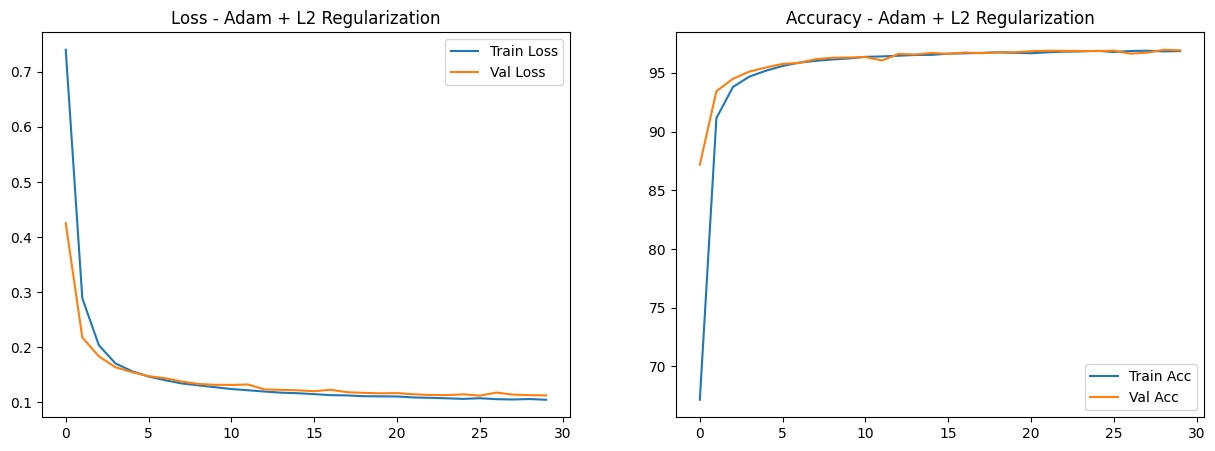

In [155]:
model_l2 = nn.Sequential(
  nn.Linear(17, 50), nn.ReLU(),
  nn.Linear(50, 40), nn.ReLU(),
  nn.Linear(40, 3)
).to(device)

optimizer_adam_l2 = optim.Adam(model_l2.parameters(), lr=0.001, weight_decay=1e-4)

print("--- Executando: Adam + L2 Regularization ---")
history_l2 = train_with_history(model_l2, optimizer_adam_l2, nn.CrossEntropyLoss(), train_loader, val_loader, n_epochs=30)
plot_history(history_l2, "Adam + L2 Regularization")

### 2. Testando SGD com Momentum
O SGD (Stochastic Gradient Descent) com Momentum é conhecido por encontrar mínimos locais que generalizam melhor que o Adam em certos casos.


--- Executando: SGD + Momentum ---
Epoch 1/30 -> Train Loss: 0.8108, Train Acc: 65.31% | Val Loss: 0.6114, Val Acc: 72.97%
Epoch 2/30 -> Train Loss: 0.4757, Train Acc: 80.27% | Val Loss: 0.3305, Val Acc: 90.31%
Epoch 3/30 -> Train Loss: 0.2781, Train Acc: 91.80% | Val Loss: 0.2392, Val Acc: 93.13%
Epoch 4/30 -> Train Loss: 0.2248, Train Acc: 93.27% | Val Loss: 0.2088, Val Acc: 94.21%
Epoch 5/30 -> Train Loss: 0.1988, Train Acc: 94.04% | Val Loss: 0.1891, Val Acc: 94.47%
Epoch 6/30 -> Train Loss: 0.1820, Train Acc: 94.58% | Val Loss: 0.1759, Val Acc: 95.21%
Epoch 7/30 -> Train Loss: 0.1681, Train Acc: 95.09% | Val Loss: 0.1686, Val Acc: 95.20%
Epoch 8/30 -> Train Loss: 0.1621, Train Acc: 95.24% | Val Loss: 0.1597, Val Acc: 95.57%
Epoch 9/30 -> Train Loss: 0.1542, Train Acc: 95.46% | Val Loss: 0.1543, Val Acc: 95.62%
Epoch 10/30 -> Train Loss: 0.1489, Train Acc: 95.65% | Val Loss: 0.1497, Val Acc: 95.88%
Epoch 11/30 -> Train Loss: 0.1441, Train Acc: 95.76% | Val Loss: 0.1454, Val Acc: 9

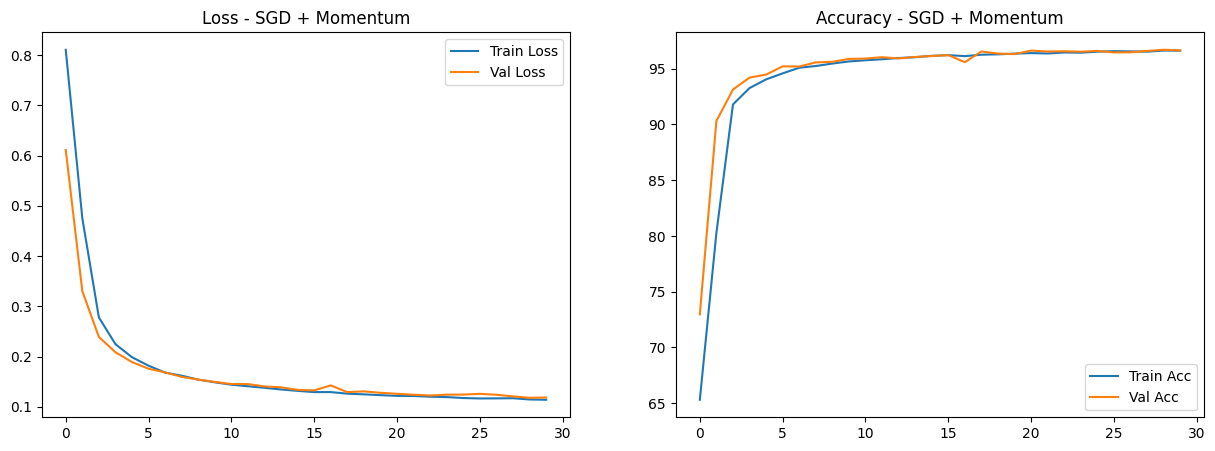

In [156]:
model_sgd = nn.Sequential(
  nn.Linear(17, 50), nn.ReLU(),
  nn.Linear(50, 40), nn.ReLU(),
  nn.Linear(40, 3)
).to(device)

optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)

print("\n--- Executando: SGD + Momentum ---")
history_sgd = train_with_history(model_sgd, optimizer_sgd, nn.CrossEntropyLoss(), train_loader, val_loader, n_epochs=30)
plot_history(history_sgd, "SGD + Momentum")

Ao testa os modelos com outros modelos de otimização com regularização temos que o modelo Adam com Regularização L2 (Weight Decay), performou ligeiramente melhor no geral que o  SGD com Momentum